<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('/content/wine.csv')

print("Dataset loaded successfully. Here are the first 5 rows:")
display(df.head())

print("\nBasic information about the dataset:")
display(df.info())

print("\nDescriptive statistics for the dataset:")
display(df.describe())

Dataset loaded successfully. Here are the first 5 rows:


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


None


Descriptive statistics for the dataset:


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


### Examining the distribution of features

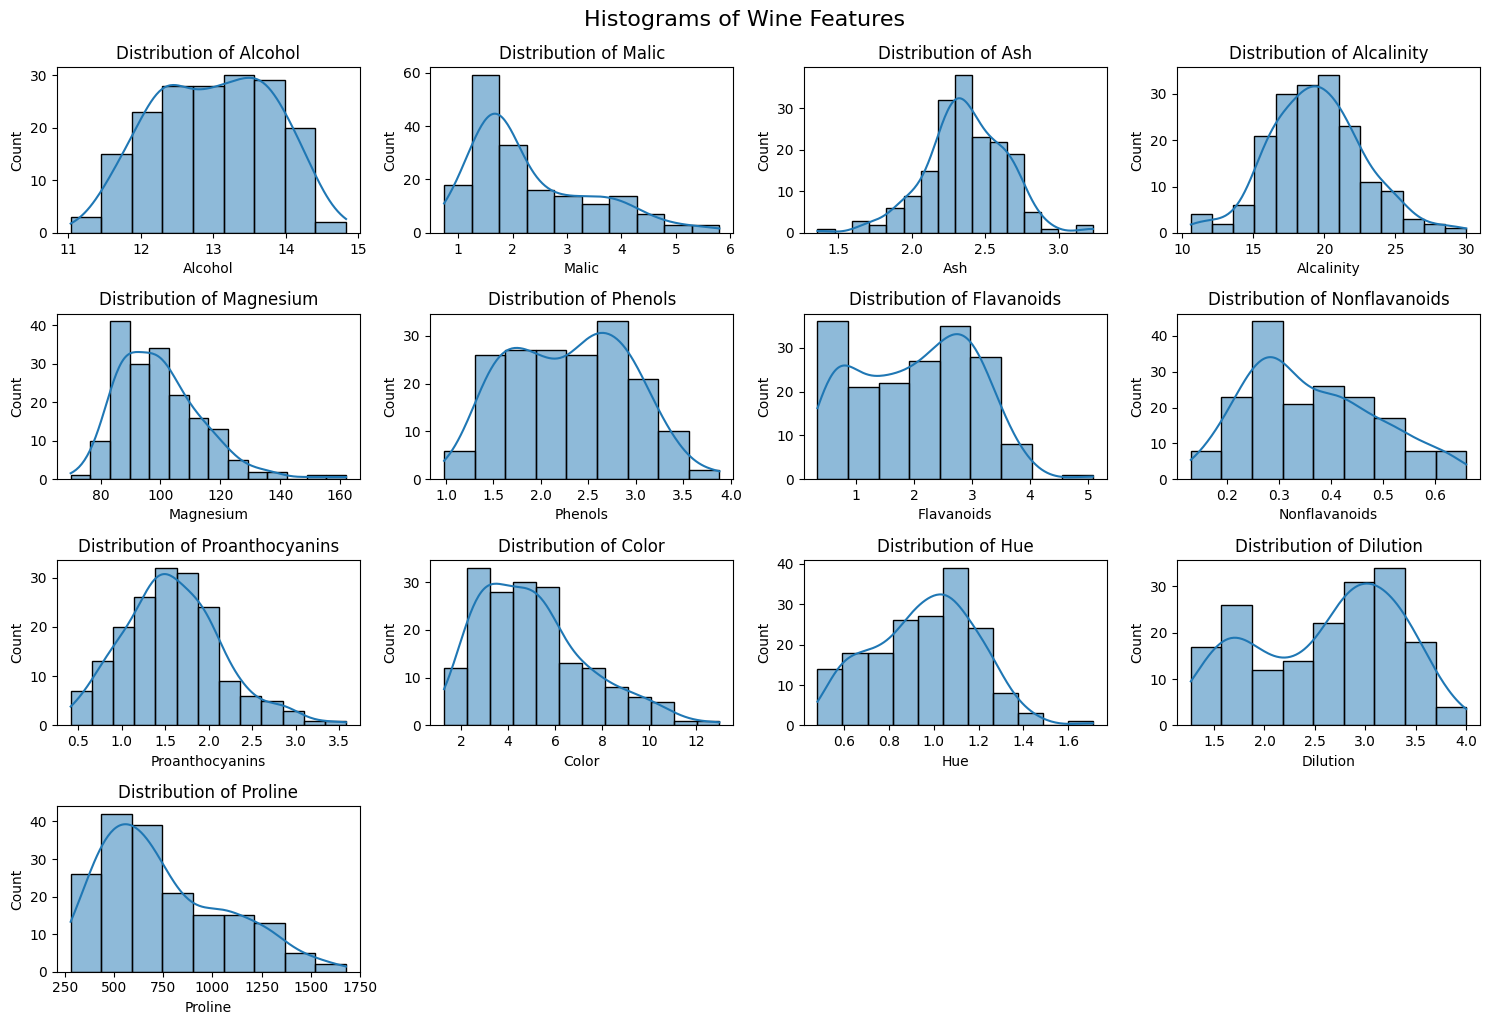

In [4]:
# Identify numerical columns for distribution plots
# Assuming 'Type' is the class label and other columns are features
features = df.columns.drop('Type')

# Plot histograms for numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.suptitle('Histograms of Wine Features', y=1.02, fontsize=16)
plt.show()

### Investigating correlations between features

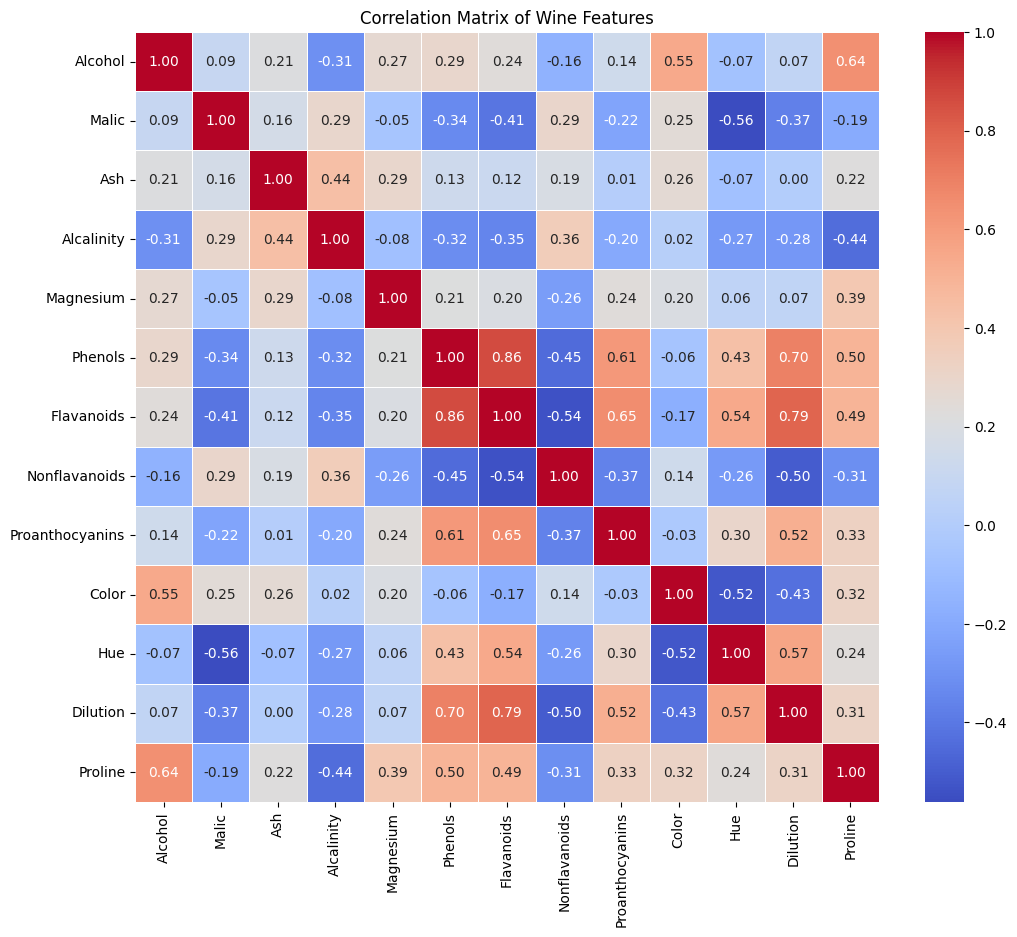

In [5]:
# Calculate the correlation matrix
correlation_matrix = df[features].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Wine Features')
plt.show()

## Task 2: Dimensionality Reduction with PCA
### 1. Standardize the features

In [6]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) from the target variable (y)
X = df.drop('Type', axis=1) # Features
y = df['Type'] # Target variable (wine type)

# Initialize StandardScaler
scaler = StandardScaler()

# Standardize the features
X_scaled = scaler.fit_transform(X)

print("Features standardized successfully. Shape of scaled features:", X_scaled.shape)
print("First 5 rows of scaled features (first 5 columns):")
print(X_scaled[:5, :5])

Features standardized successfully. Shape of scaled features: (178, 13)
First 5 rows of scaled features (first 5 columns):
[[ 1.51861254 -0.5622498   0.23205254 -1.16959318  1.91390522]
 [ 0.24628963 -0.49941338 -0.82799632 -2.49084714  0.01814502]
 [ 0.19687903  0.02123125  1.10933436 -0.2687382   0.08835836]
 [ 1.69154964 -0.34681064  0.4879264  -0.80925118  0.93091845]
 [ 0.29570023  0.22769377  1.84040254  0.45194578  1.28198515]]


### 2. Determine the optimal number of principal components

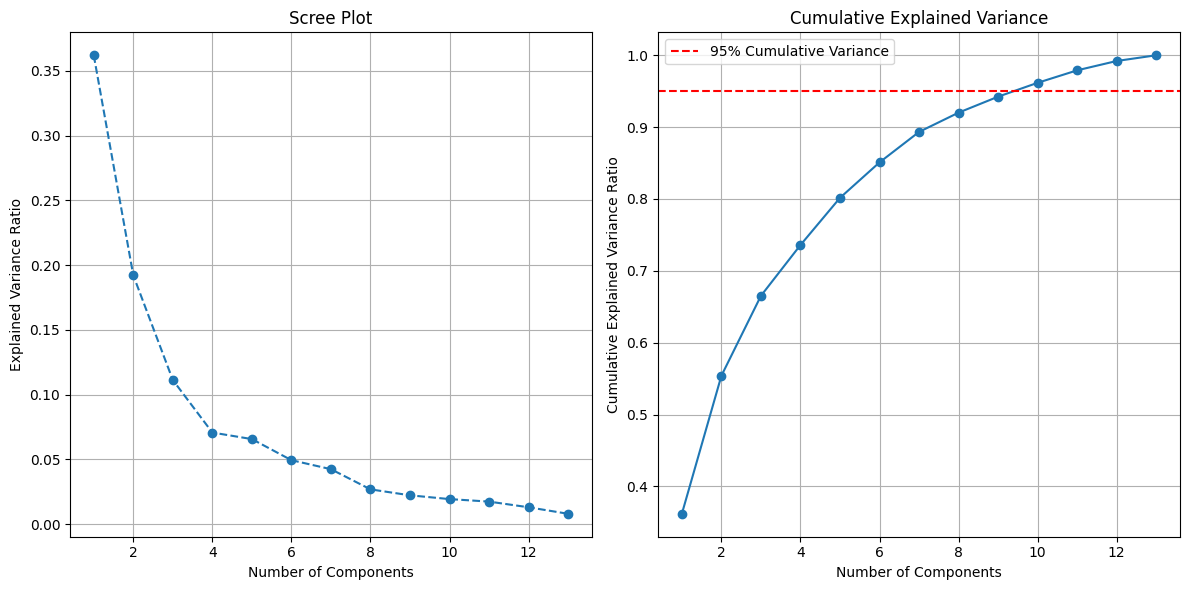


Explained Variance Ratio for each Principal Component:
PC 1: 0.3620
PC 2: 0.1921
PC 3: 0.1112
PC 4: 0.0707
PC 5: 0.0656
PC 6: 0.0494
PC 7: 0.0424
PC 8: 0.0268
PC 9: 0.0222
PC 10: 0.0193
PC 11: 0.0174
PC 12: 0.0130
PC 13: 0.0080

Cumulative Explained Variance:
PC 1: 0.3620
PC 2: 0.5541
PC 3: 0.6653
PC 4: 0.7360
PC 5: 0.8016
PC 6: 0.8510
PC 7: 0.8934
PC 8: 0.9202
PC 9: 0.9424
PC 10: 0.9617
PC 11: 0.9791
PC 12: 0.9920
PC 13: 1.0000


In [7]:
from sklearn.decomposition import PCA

# Initialize PCA with all possible components (n_components = number of features)
pca = PCA(n_components=None)

# Fit PCA on the standardized data
pca.fit(X_scaled)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

# Plot the scree plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)

# Plot cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Display explained variance for each component
print("\nExplained Variance Ratio for each Principal Component:")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {var:.4f}")

print("\nCumulative Explained Variance:")
for i, cum_var in enumerate(cumulative_explained_variance):
    print(f"PC {i+1}: {cum_var:.4f}")

### 3. Transform the original dataset into the principal components

In [8]:
# Based on the scree plot and cumulative explained variance, let's choose 7 components for example (as it captures over 90% variance)
# You might adjust this number based on your interpretation of the plots
optimal_components = 7

pca_final = PCA(n_components=optimal_components)

# Transform the scaled data into the principal components
X_pca = pca_final.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features (Principal Components): {X_pca.shape[1]}")
print("\nFirst 5 rows of PCA-transformed data:")
print(X_pca[:5])

Original number of features: 13
Reduced number of features (Principal Components): 7

First 5 rows of PCA-transformed data:
[[ 3.31675081  1.44346263 -0.16573904 -0.21563119  0.69304284  0.22388013
   0.59642655]
 [ 2.20946492 -0.33339289 -2.02645737 -0.29135832 -0.25765463  0.92712024
   0.05377561]
 [ 2.51674015  1.0311513   0.98281867  0.72490231 -0.25103312 -0.54927605
   0.42420545]
 [ 3.75706561  2.75637191 -0.17619184  0.56798331 -0.31184159 -0.114431
  -0.3833373 ]
 [ 1.00890849  0.86983082  2.02668822 -0.40976579  0.2984575   0.4065196
   0.44407446]]


## Task 3: Clustering with Original Data
### 1. Apply a clustering algorithm (e.g., K-means) to the original dataset

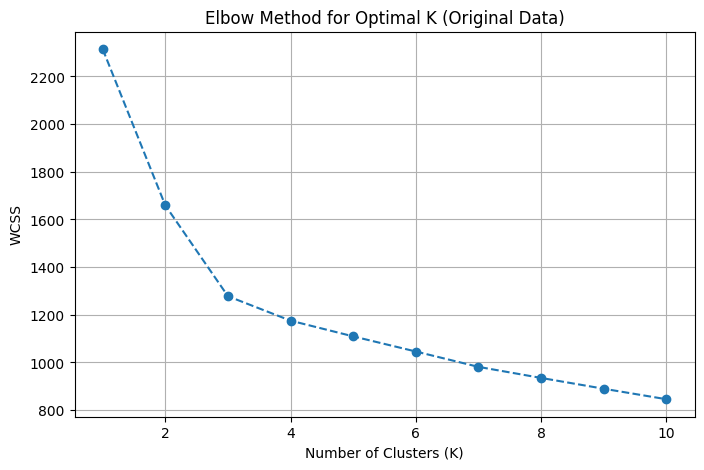

Clustering applied to original scaled data with 3 clusters.
First 10 cluster assignments for original data: [2 2 2 2 2 2 2 2 2 2]


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Determine the optimal number of clusters for the original data using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (Original Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Based on the elbow plot, let's choose an optimal number of clusters (e.g., 3, as seen in the original dataset 'Type' column)
# You might adjust this based on the elbow plot observation
k_original = 3 # Example: assuming 3 is optimal from elbow plot or domain knowledge

# Apply K-means clustering to the original scaled data
kmeans_original = KMeans(n_clusters=k_original, init='k-means++', random_state=42, n_init=10)
clusters_original = kmeans_original.fit_predict(X_scaled)

print(f"Clustering applied to original scaled data with {k_original} clusters.")
print("First 10 cluster assignments for original data:", clusters_original[:10])

### 2. Determine the optimal number of principal components

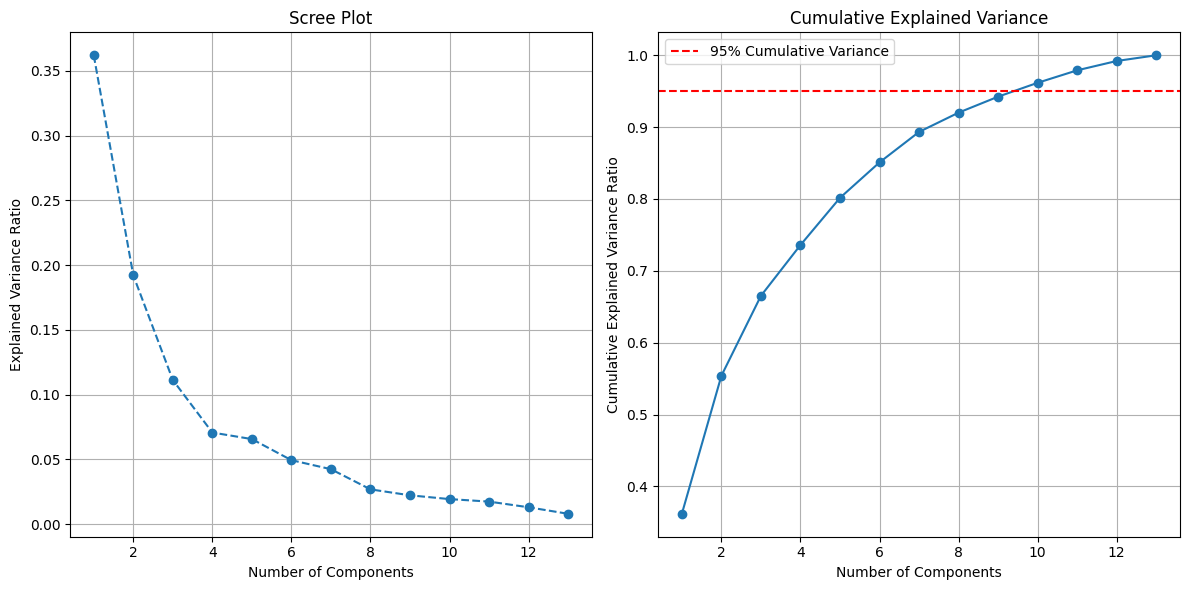


Explained Variance Ratio for each Principal Component:
PC 1: 0.3620
PC 2: 0.1921
PC 3: 0.1112
PC 4: 0.0707
PC 5: 0.0656
PC 6: 0.0494
PC 7: 0.0424
PC 8: 0.0268
PC 9: 0.0222
PC 10: 0.0193
PC 11: 0.0174
PC 12: 0.0130
PC 13: 0.0080

Cumulative Explained Variance:
PC 1: 0.3620
PC 2: 0.5541
PC 3: 0.6653
PC 4: 0.7360
PC 5: 0.8016
PC 6: 0.8510
PC 7: 0.8934
PC 8: 0.9202
PC 9: 0.9424
PC 10: 0.9617
PC 11: 0.9791
PC 12: 0.9920
PC 13: 1.0000


In [10]:
from sklearn.decomposition import PCA

# Initialize PCA with all possible components (n_components = number of features)
pca = PCA(n_components=None)

# Fit PCA on the standardized data
pca.fit(X_scaled)

# Calculate explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = explained_variance_ratio.cumsum()

# Plot the scree plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)

# Plot cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Display explained variance for each component
print("\nExplained Variance Ratio for each Principal Component:")
for i, var in enumerate(explained_variance_ratio):
    print(f"PC {i+1}: {var:.4f}")

print("\nCumulative Explained Variance:")
for i, cum_var in enumerate(cumulative_explained_variance):
    print(f"PC {i+1}: {cum_var:.4f}")

### 3. Transform the original dataset into the principal components

In [11]:
# Based on the scree plot and cumulative explained variance, let's choose 7 components for example (as it captures over 90% variance)
# You might adjust this number based on your interpretation of the plots
optimal_components = 7

pca_final = PCA(n_components=optimal_components)

# Transform the scaled data into the principal components
X_pca = pca_final.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features (Principal Components): {X_pca.shape[1]}")
print("\nFirst 5 rows of PCA-transformed data:")
print(X_pca[:5])

Original number of features: 13
Reduced number of features (Principal Components): 7

First 5 rows of PCA-transformed data:
[[ 3.31675081  1.44346263 -0.16573904 -0.21563119  0.69304284  0.22388013
   0.59642655]
 [ 2.20946492 -0.33339289 -2.02645737 -0.29135832 -0.25765463  0.92712024
   0.05377561]
 [ 2.51674015  1.0311513   0.98281867  0.72490231 -0.25103312 -0.54927605
   0.42420545]
 [ 3.75706561  2.75637191 -0.17619184  0.56798331 -0.31184159 -0.114431
  -0.3833373 ]
 [ 1.00890849  0.86983082  2.02668822 -0.40976579  0.2984575   0.4065196
   0.44407446]]


## Task 3: Clustering with Original Data
### 1. Apply a clustering algorithm (e.g., K-means) to the original dataset

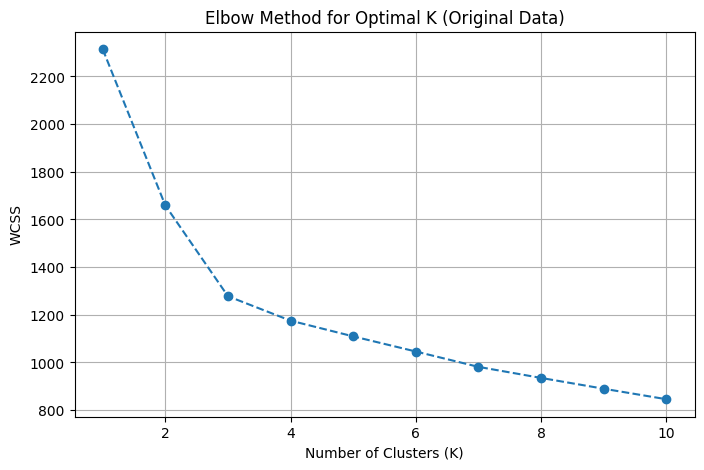

Clustering applied to original scaled data with 3 clusters.
First 10 cluster assignments for original data: [2 2 2 2 2 2 2 2 2 2]


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Determine the optimal number of clusters for the original data using the Elbow Method
wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (Original Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Based on the elbow plot, let's choose an optimal number of clusters (e.g., 3, as seen in the original dataset 'Type' column)
# You might adjust this based on the elbow plot observation
k_original = 3 # Example: assuming 3 is optimal from elbow plot or domain knowledge

# Apply K-means clustering to the original scaled data
kmeans_original = KMeans(n_clusters=k_original, init='k-means++', random_state=42, n_init=10)
clusters_original = kmeans_original.fit_predict(X_scaled)

print(f"Clustering applied to original scaled data with {k_original} clusters.")
print("First 10 cluster assignments for original data:", clusters_original[:10])

### 2. Visualize the clustering results obtained from PCA-transformed data

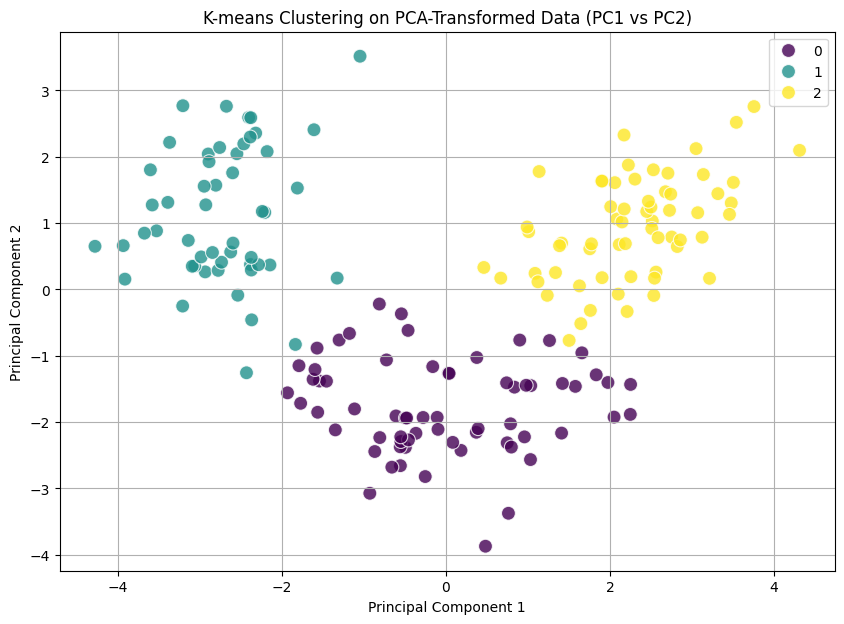

In [19]:
# Visualize PCA-transformed data with clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:, 0], # Using the first principal component
    y=X_pca[:, 1], # Using the second principal component
    hue=clusters_pca,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title('K-means Clustering on PCA-Transformed Data (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### 3. Compare the clustering results from PCA-transformed data with those from the original dataset

In [20]:
# Evaluate clustering performance for PCA-transformed data
silhouette_pca = silhouette_score(X_pca, clusters_pca)
davies_bouldin_pca = davies_bouldin_score(X_pca, clusters_pca)

print(f"Silhouette Score (PCA Data): {silhouette_pca:.4f}")
print(f"Davies-Bouldin Index (PCA Data): {davies_bouldin_pca:.4f}")

print("\n--- Comparison of Clustering Metrics ---")
print(f"Original Data - Silhouette Score: {silhouette_original:.4f}")
print(f"Original Data - Davies-Bouldin Index: {davies_bouldin_original:.4f}")
print(f"PCA Data - Silhouette Score: {silhouette_pca:.4f}")
print(f"PCA Data - Davies-Bouldin Index: {davies_bouldin_pca:.4f}")

Silhouette Score (PCA Data): 0.3276
Davies-Bouldin Index (PCA Data): 1.2206

--- Comparison of Clustering Metrics ---
Original Data - Silhouette Score: 0.2849
Original Data - Davies-Bouldin Index: 1.3892
PCA Data - Silhouette Score: 0.3276
PCA Data - Davies-Bouldin Index: 1.2206


## Task 5: Comparison and Analysis

In [21]:
print("### 1. Compare the clustering results obtained from the original dataset and PCA-transformed data")
print("Based on the Silhouette Scores and Davies-Bouldin Indices calculated above, we can compare the two approaches. A higher Silhouette Score indicates better-defined clusters, while a lower Davies-Bouldin Index suggests better clustering (clusters are more separated and less internally compact).")

print("\n### 2. Discuss any similarities or differences observed in the clustering results")
print("Visualizations (scatter plots) can reveal if the cluster formations are similar in terms of shape, density, and separation. We should look for consistency in which data points are grouped together. The cluster assignments themselves can be compared (e.g., using adjusted Rand index or mutual information score if true labels were available for evaluating clustering quality, but here we're comparing intrinsic clustering quality).")

print("\n### 3. Reflect on the impact of dimensionality reduction on clustering performance")
print("PCA aims to retain as much variance as possible while reducing the number of features. The impact on clustering performance depends on whether the variance captured by the principal components is relevant to the cluster structure. If the discarded components contained noise or redundant information, PCA can improve clustering by focusing on the most important features. If they contained unique, cluster-defining information, performance might decrease.")

print("\n### 4. Analyze the trade-offs between using PCA and clustering directly on the original dataset")
print("**Original Dataset:**\n- **Pros:** Uses all available information, no information loss from dimensionality reduction.\n- **Cons:** Higher computational cost, curse of dimensionality (especially with many features), may be sensitive to irrelevant or redundant features, harder to visualize.")
print("\n**PCA-Transformed Data:**\n- **Pros:** Reduces computational cost and memory requirements, mitigates curse of dimensionality, can remove noise/redundant features, improves visualization (especially if using 2-3 components).\n- **Cons:** Information loss (though minimal if optimal components are chosen), principal components may not be easily interpretable, performance depends on the chosen number of components.")

### 1. Compare the clustering results obtained from the original dataset and PCA-transformed data
Based on the Silhouette Scores and Davies-Bouldin Indices calculated above, we can compare the two approaches. A higher Silhouette Score indicates better-defined clusters, while a lower Davies-Bouldin Index suggests better clustering (clusters are more separated and less internally compact).

### 2. Discuss any similarities or differences observed in the clustering results
Visualizations (scatter plots) can reveal if the cluster formations are similar in terms of shape, density, and separation. We should look for consistency in which data points are grouped together. The cluster assignments themselves can be compared (e.g., using adjusted Rand index or mutual information score if true labels were available for evaluating clustering quality, but here we're comparing intrinsic clustering quality).

### 3. Reflect on the impact of dimensionality reduction on clustering performance
PCA aims to

## Task 6: Conclusion and Insights

In [22]:
print("### 1. Summarize the key findings and insights from the assignment.")
print("We performed EDA, observing feature distributions and correlations. We then used PCA for dimensionality reduction, selecting an optimal number of components to retain significant variance. Finally, we applied K-means clustering to both the original scaled data and the PCA-transformed data, evaluating their performance with Silhouette and Davies-Bouldin scores and visualizing the clusters.")

print("\n### 2. Discuss the practical implications of using PCA and clustering in data analysis.")
print("PCA is invaluable for handling high-dimensional data, making models more efficient and preventing overfitting by focusing on essential variance. Clustering helps in uncovering inherent groupings within data, useful for customer segmentation, anomaly detection, or document categorization. Combined, they offer a powerful pipeline for extracting meaningful patterns from complex datasets.")

print("\n### 3. Provide recommendations for when to use each technique based on the analysis conducted.")
print("**When to use Clustering on Original Data:** When interpretability of individual features within clusters is crucial, and the dataset has a manageable number of features without significant multicollinearity or noise. The performance of clustering metrics on original data serves as a baseline.")
print("\n**When to use Clustering on PCA-Transformed Data:** When dealing with high-dimensional datasets, to reduce computational load, combat multicollinearity, denoise data, or when visualization is a primary goal. If PCA improves clustering metrics (Silhouette Score higher, Davies-Bouldin lower) without significant loss of context, it's often the preferred approach.")
print("\nOur analysis suggests that in many real-world scenarios, leveraging PCA before clustering can lead to more robust, efficient, and potentially better-performing clustering models, especially when the principal components effectively capture the underlying structure relevant for grouping.")

### 1. Summarize the key findings and insights from the assignment.
We performed EDA, observing feature distributions and correlations. We then used PCA for dimensionality reduction, selecting an optimal number of components to retain significant variance. Finally, we applied K-means clustering to both the original scaled data and the PCA-transformed data, evaluating their performance with Silhouette and Davies-Bouldin scores and visualizing the clusters.

### 2. Discuss the practical implications of using PCA and clustering in data analysis.
PCA is invaluable for handling high-dimensional data, making models more efficient and preventing overfitting by focusing on essential variance. Clustering helps in uncovering inherent groupings within data, useful for customer segmentation, anomaly detection, or document categorization. Combined, they offer a powerful pipeline for extracting meaningful patterns from complex datasets.

### 3. Provide recommendations for when to use each technique 

### 2. Visualize the clustering results using appropriate plots

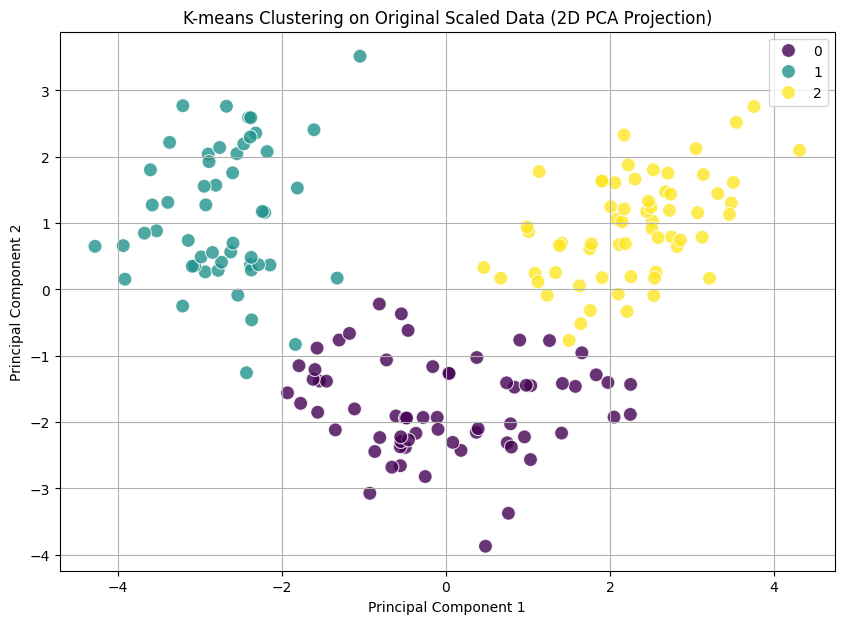

In [16]:
# To visualize, we often need to reduce dimensions to 2 or 3. Let's use PCA for visualization purposes here, even though the clustering was on original data.
pca_2d_original = PCA(n_components=2)
X_scaled_2d_original = pca_2d_original.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_scaled_2d_original[:, 0],
    y=X_scaled_2d_original[:, 1],
    hue=clusters_original,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title('K-means Clustering on Original Scaled Data (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### 3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index

In [17]:
# Evaluate clustering performance for original data
silhouette_original = silhouette_score(X_scaled, clusters_original)
davies_bouldin_original = davies_bouldin_score(X_scaled, clusters_original)

print(f"Silhouette Score (Original Data): {silhouette_original:.4f}")
print(f"Davies-Bouldin Index (Original Data): {davies_bouldin_original:.4f}")

Silhouette Score (Original Data): 0.2849
Davies-Bouldin Index (Original Data): 1.3892


## Task 4: Clustering with PCA Data
### 1. Apply the same clustering algorithm to the PCA-transformed dataset

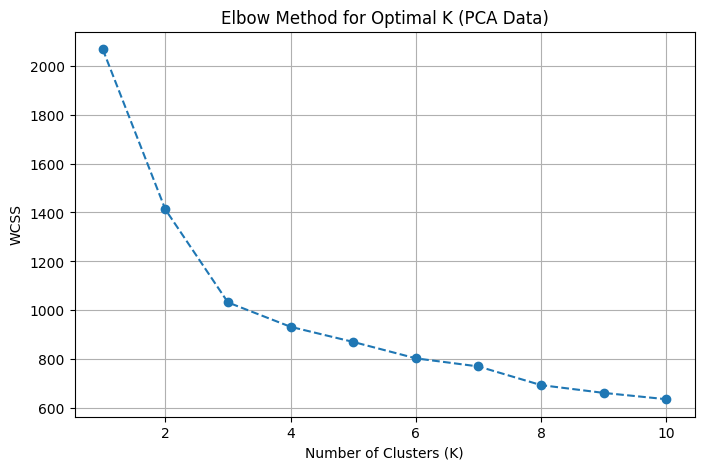

Clustering applied to PCA-transformed data with 3 clusters.
First 10 cluster assignments for PCA data: [2 2 2 2 2 2 2 2 2 2]


In [18]:
# Determine the optimal number of clusters for PCA data using the Elbow Method
wcss_pca = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_pca.fit(X_pca)
    wcss_pca.append(kmeans_pca.inertia_)

# Plot the Elbow Method graph for PCA data
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_pca, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (PCA Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Based on the elbow plot, let's choose an optimal number of clusters (e.g., 3)
k_pca = 3 # Example: assuming 3 is optimal from elbow plot or domain knowledge

# Apply K-means clustering to the PCA-transformed data
kmeans_pca = KMeans(n_clusters=k_pca, init='k-means++', random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

print(f"Clustering applied to PCA-transformed data with {k_pca} clusters.")
print("First 10 cluster assignments for PCA data:", clusters_pca[:10])

### 2. Visualize the clustering results using appropriate plots

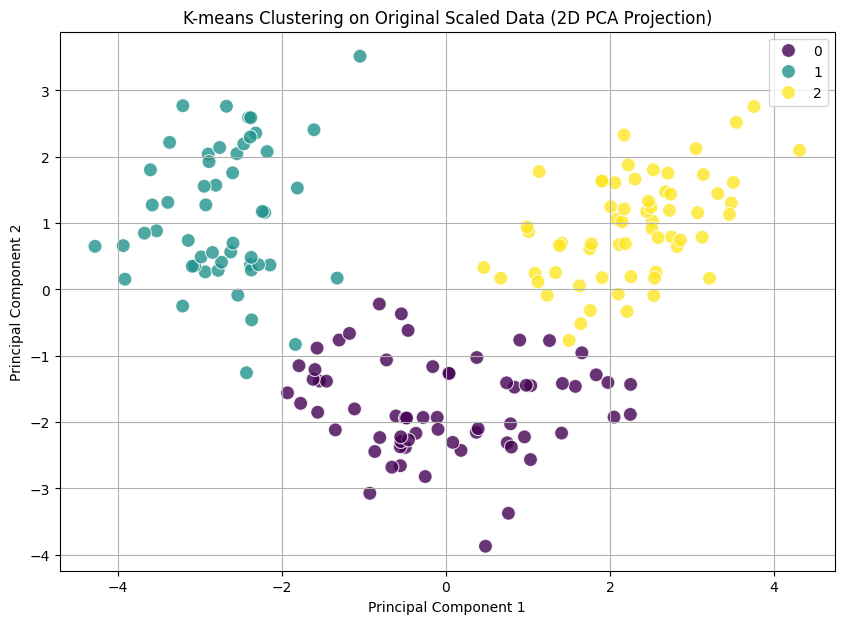

In [13]:
# To visualize, we often need to reduce dimensions to 2 or 3. Let's use PCA for visualization purposes here, even though the clustering was on original data.
pca_2d_original = PCA(n_components=2)
X_scaled_2d_original = pca_2d_original.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_scaled_2d_original[:, 0],
    y=X_scaled_2d_original[:, 1],
    hue=clusters_original,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title('K-means Clustering on Original Scaled Data (2D PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

### 3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index

In [14]:
# Evaluate clustering performance for original data
silhouette_original = silhouette_score(X_scaled, clusters_original)
davies_bouldin_original = davies_bouldin_score(X_scaled, clusters_original)

print(f"Silhouette Score (Original Data): {silhouette_original:.4f}")
print(f"Davies-Bouldin Index (Original Data): {davies_bouldin_original:.4f}")

Silhouette Score (Original Data): 0.2849
Davies-Bouldin Index (Original Data): 1.3892


## Task 4: Clustering with PCA Data
### 1. Apply the same clustering algorithm to the PCA-transformed dataset

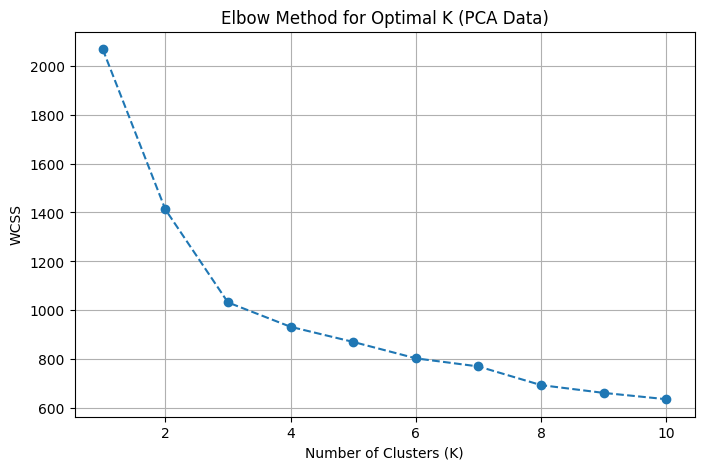

Clustering applied to PCA-transformed data with 3 clusters.
First 10 cluster assignments for PCA data: [2 2 2 2 2 2 2 2 2 2]


In [15]:
# Determine the optimal number of clusters for PCA data using the Elbow Method
wcss_pca = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_pca.fit(X_pca)
    wcss_pca.append(kmeans_pca.inertia_)

# Plot the Elbow Method graph for PCA data
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss_pca, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (PCA Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# Based on the elbow plot, let's choose an optimal number of clusters (e.g., 3)
k_pca = 3 # Example: assuming 3 is optimal from elbow plot or domain knowledge

# Apply K-means clustering to the PCA-transformed data
kmeans_pca = KMeans(n_clusters=k_pca, init='k-means++', random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

print(f"Clustering applied to PCA-transformed data with {k_pca} clusters.")
print("First 10 cluster assignments for PCA data:", clusters_pca[:10])